In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_csv("/content/diabetes.csv")

# Display first 5 rows
print(data.head())



# Dataset info
print(data.info())

# Summary statistics
print(data.describe())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768

In [25]:
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


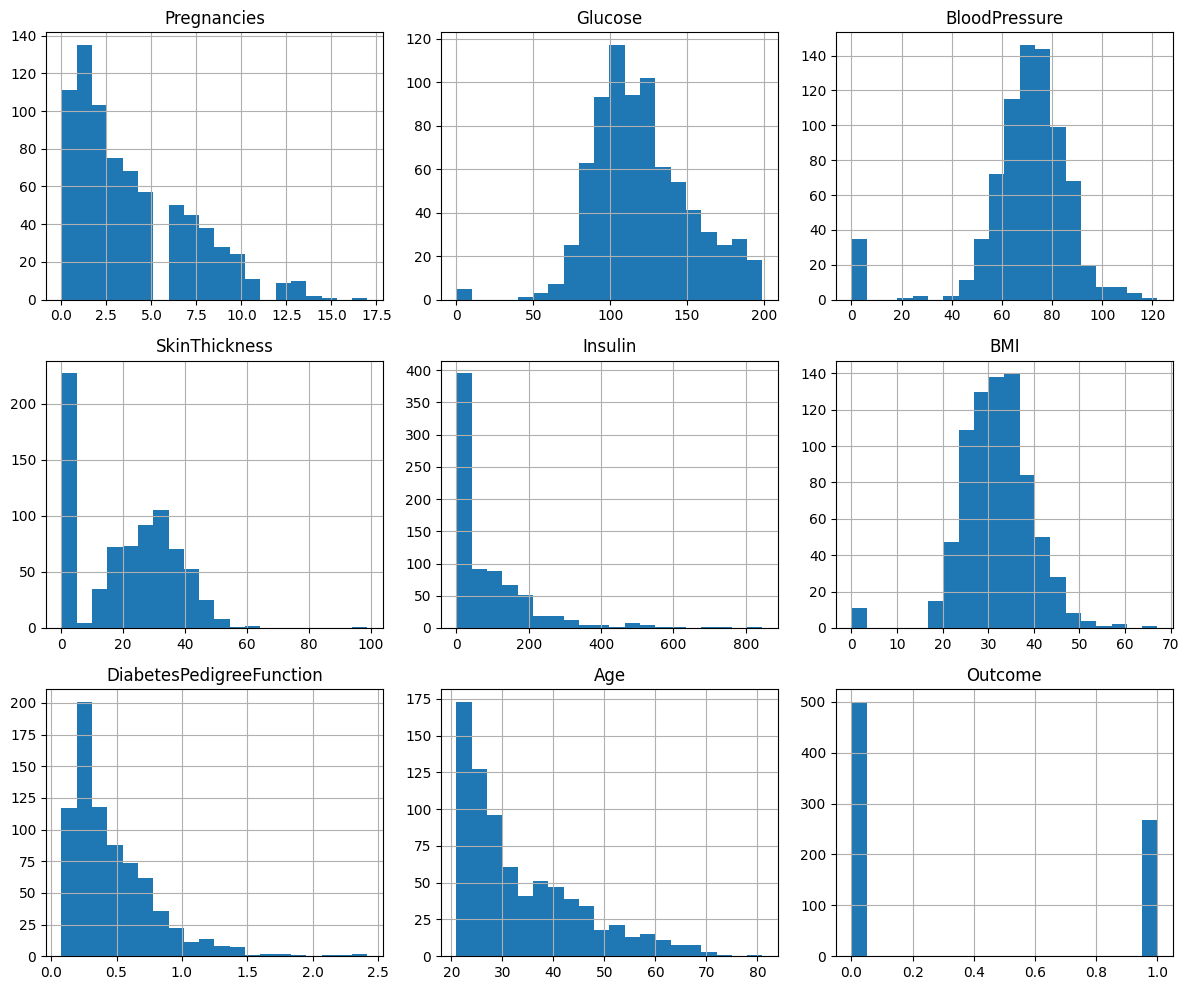

In [26]:
data.hist(figsize=(12,10),bins=20)
plt.tight_layout()
plt.show()

In [27]:
data.shape

(768, 9)

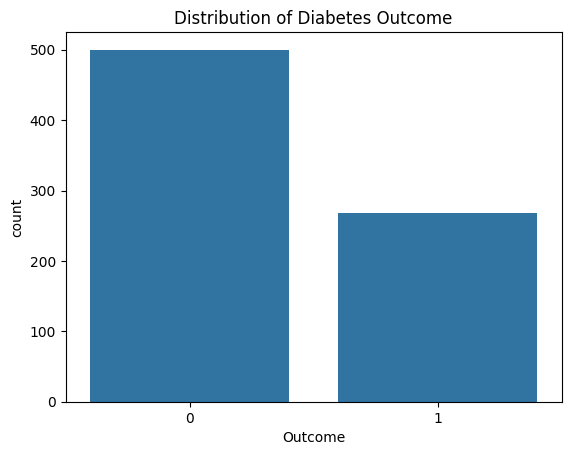

In [28]:
# Count plot of target variable
sns.countplot(x="Outcome", data=data)
plt.title("Distribution of Diabetes Outcome")
plt.show()

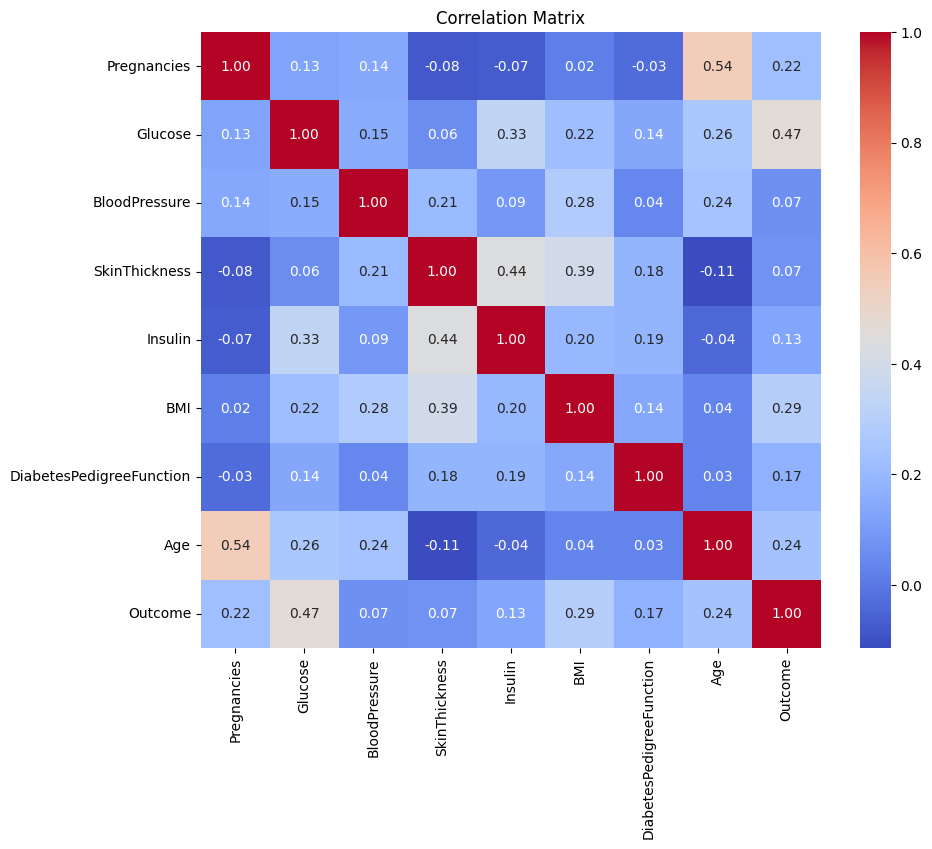

In [29]:
# Calculate correlation matrix
corr = data.corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

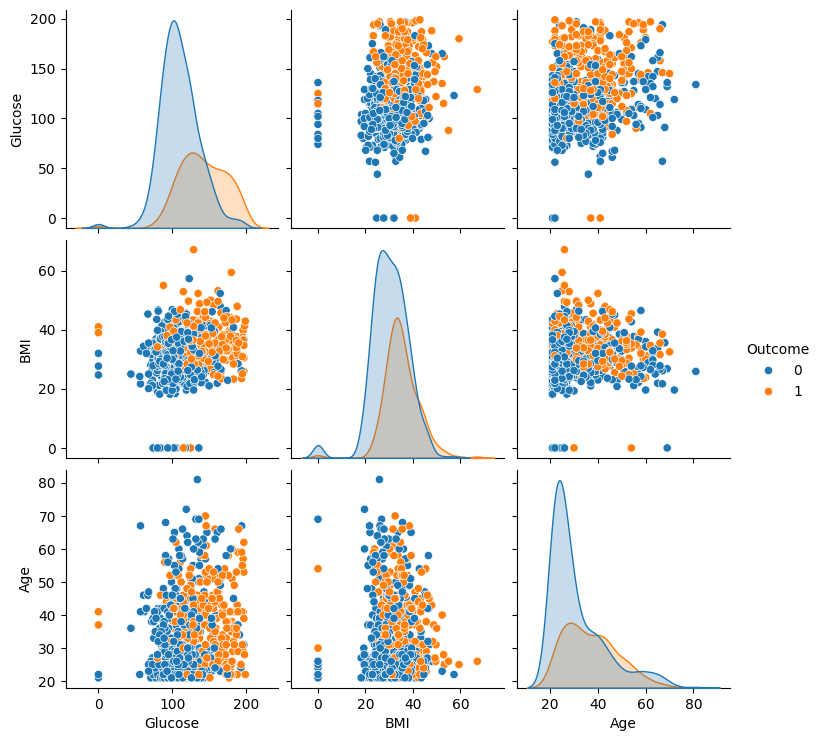

In [30]:
# Pair plot for selected features
sns.pairplot(data[["Glucose", "BMI", "Age", "Outcome"]], hue="Outcome")
plt.show()

In [31]:
# Count zero values in each column
for col in ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]:
    print(col, (data[col] == 0).sum())

Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11


In [32]:
# Replace zeros with median values
for col in ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]:
    median = data[col].median()
    data[col] = data[col].replace(0, median)

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data.drop("Outcome", axis=1))

X = pd.DataFrame(scaled_data, columns=data.columns[:-1])
y = data["Outcome"]

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [35]:
from sklearn.linear_model import LogisticRegression

# Create model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [36]:
# Predictions
y_pred = model.predict(X_test)

In [37]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7077922077922078
Confusion Matrix:
 [[82 18]
 [27 27]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



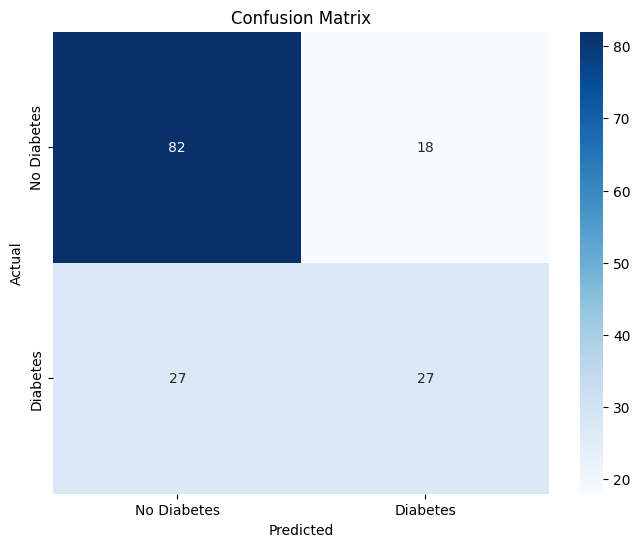

In [38]:
# Import necessary libraries for plotting
from sklearn.metrics import roc_curve, auc

# 1. Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Create income categories based on quantiles
bins=[0,1]
data["Values"] = pd.cut(data["Outcome"],bins=bins)

plt.figure(figsize=(16,8))
for i, col in enumerate(data.columns[:-2], 1):  # Outcome
    plt.subplot(2, 4, i)
    sns.boxplot(x="Values", y=col, data=data, palette="Set2")
    plt.title(f"{col} vs Outcome")
    
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(2,4,1)
sns.boxplot(data=data,x = "Outcome",y="Pregnancies")
plt.title("Pregnancies and Outcome")

plt.subplot(2,4,2)
sns.boxplot(data=data,x = "Outcome",y="Glucose")
plt.title("Glucose and Outcome")

plt.subplot(2,4,3)
sns.boxplot(data=data,x = "Outcome",y="BloodPressure")
plt.title("BloodPressure and Outcome")

plt.subplot(2,4,4)
sns.boxplot(data=data,x = "Outcome",y="SkinThickness")
plt.title("SkinThickness and Outcome")

plt.subplot(2,4,5)
sns.boxplot(data=data,x = "Outcome",y="Insulin")
plt.title("Insulin and Outcome")

plt.subplot(2,4,6)
sns.boxplot(data=data,x = "Outcome",y="BMI")
plt.title("BMI and Outcome")

plt.subplot(2,4,7)
sns.boxplot(data=data,x = "Outcome",y="DiabetesPedigreeFunction")
plt.title("DiabetesPedigreeFunction and Outcome")

plt.subplot(2,4,8)
sns.boxplot(data=data,x = "Outcome",y="Age")
plt.title("Age and Outcome")
plt.tight_layout()
plt.show()

In [ ]:
# Feature importance using model coefficients
importance = model.coef_[0]
for i, col in enumerate(X.columns):
    print(f"{col}: {importance[i]}")
    

Pregnancies: 0.38214523269923706
Glucose: 1.2260759962626444
BloodPressure: -0.053215958732901913
SkinThickness: 0.02832186369686114
Insulin: -0.14295308960178751
BMI: 0.7065950492674601
DiabetesPedigreeFunction: 0.2457948340368867
Age: 0.1372378572978456


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": [""
    "", "l2"],
    "solver": ["liblinear", "saga"]
}

grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring="accuracy")
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best Score: 0.7818072770891644


In [41]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
print("Cross-validation accuracy scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation accuracy scores: [0.75324675 0.74025974 0.76623377 0.79738562 0.76470588]
Mean accuracy: 0.7643663526016468


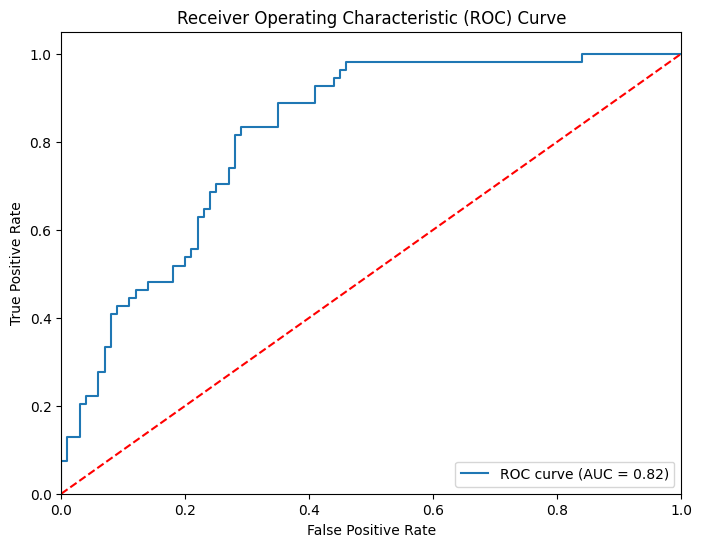

Error Rate: 0.29220779220779225


In [45]:
from sklearn.metrics import roc_curve, auc

# Calculate the predicted probabilities for the positive class (Diabetes)
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate False Positive Rate (FPR) and True Positive Rate (TPR)
# fpr: rate of incorrectly predicted positive observations
# tpr: rate of correctly predicted positive observations
fpr, tpr, _ = roc_curve(y_test, y_prob)

# Calculate the Area Under the Curve (AUC)
# AUC represents the degree or measure of separability achieved by the model
roc_auc = auc(fpr, tpr)

# Plot the ROC Curve
plt.figure(figsize=(8, 6))  # Set the figure size
plt.plot(fpr, tpr, label='ROC curve (AUC = {:.2f})'.format(roc_auc))  # Plot the ROC curve
plt.plot([0, 1], [0, 1], 'r--')  # Plot a diagonal line (baseline) for reference
plt.xlim([0.0, 1.0])  # Set x-axis limits
plt.ylim([0.0, 1.05])  # Set y-axis limits
plt.xlabel('False Positive Rate')  # Label for x-axis
plt.ylabel('True Positive Rate')  # Label for y-axis
plt.title('Receiver Operating Characteristic (ROC) Curve')  # Title of the plot
plt.legend(loc='lower right')  # Position the legend
plt.show()  # Display the plot

# Calculate and display the error rate
# Error rate is defined as the proportion of incorrect predictions
error_rate = 1 - accuracy_score(y_test, model.predict(X_test))
print("Error Rate:", error_rate)  # Print the error rate